<a href="https://colab.research.google.com/github/IamMubashir/lab-2_digital-image-proceing-/blob/main/Lab%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment: Sampling and Quantization of Digital Images

### 1. Objective
* To understand spatial sampling of an image.
* To understand intensity quantization.
* To perform downsampling using NumPy slicing.
* To reduce intensity levels to 4-bit using quantization.

### 2. Theory
Sampling refers to reducing the spatial resolution of an image. It decreases the number of pixels by skipping rows and columns.
Quantization refers to reducing the number of intensity levels in an image. For example, converting 8-bit (256 levels) image into 4-bit (16 levels). This reduces image detail and introduces intensity loss.

### 3. Software Requirements
* Python 3.x
* OpenCV (cv2)
* NumPy

### 4. Procedure

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = '/content/Screenshot 2025-12-04 102320.png'
print(f"Using image: {image_path}")

Using image: /content/Screenshot 2025-12-04 102320.png


#### Step 2: Read the image in grayscale mode.

In [27]:
gray_img_orig = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if gray_img_orig is None:
    print(f"Error: Could not load grayscale image from {image_path}.")
else:
    print("Grayscale image loaded successfully!")
    print(f"Original Grayscale Image Shape: {gray_img_orig.shape}")

Grayscale image loaded successfully!
Original Grayscale Image Shape: (357, 644)


#### Step 3: Apply sampling using `img[::2, ::2]`.

In [28]:
if gray_img_orig is not None:
    sampled_img_2x = gray_img_orig[::2, ::2]
    print(f"Sampled Image (2x step) Shape: {sampled_img_2x.shape}")

Sampled Image (2x step) Shape: (179, 322)


#### Step 4: Apply quantization using `(img // 16) * 16` (for 4-bit levels).
An 8-bit image has 256 levels (0-255). To reduce to 4-bit, we need 16 levels (2^4).
We divide by (256 / 16) = 16 to get 16 intensity groups, then multiply by 16 to scale them back.

In [29]:
if gray_img_orig is not None:
    quantized_img_4bit = (gray_img_orig // 16) * 16
    print(f"Quantized Image (4-bit) Data Type: {quantized_img_4bit.dtype}")
    print(f"Quantized Image (4-bit) unique levels: {np.unique(quantized_img_4bit).size}")

Quantized Image (4-bit) Data Type: uint8
Quantized Image (4-bit) unique levels: 16


#### Step 5: Display original, sampled, and quantized images.

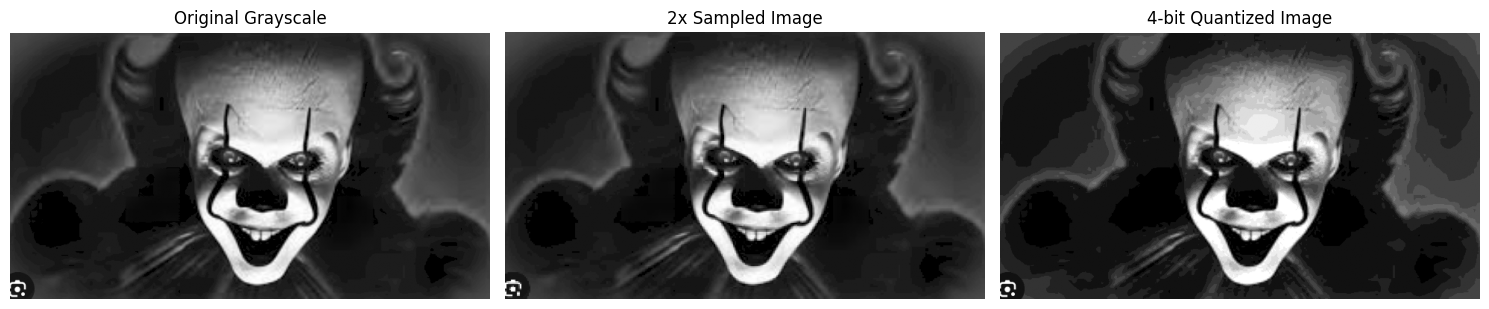

In [30]:
if gray_img_orig is not None and sampled_img_2x is not None and quantized_img_4bit is not None:
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(gray_img_orig, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled_img_2x, cmap='gray')
    plt.title('2x Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized_img_4bit, cmap='gray')
    plt.title('4-bit Quantized Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### 5. Explanation
`img[::2, ::2]` means selecting every 2nd row and every 2nd column. This reduces the resolution to half in both directions.
In quantization, dividing by 16 reduces 256 intensity levels to 16 levels. Multiplying by 16 maps them back to visible intensity ranges.

### 6. Result
The image was successfully downsampled and quantized to 4-bit intensity levels.

### 7. Lab Tasks for Students

#### Task 1: Perform sampling using step size 3.

Sampled Image (3x step) Shape: (119, 215)


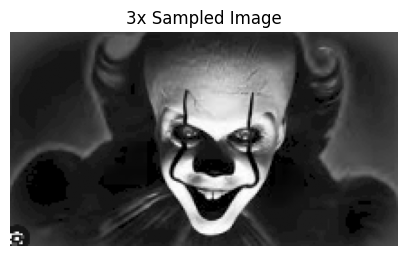

In [31]:
if gray_img_orig is not None:
    sampled_img_3x = gray_img_orig[::3, ::3]
    print(f"Sampled Image (3x step) Shape: {sampled_img_3x.shape}")
    plt.figure(figsize=(5, 5))
    plt.imshow(sampled_img_3x, cmap='gray')
    plt.title('3x Sampled Image')
    plt.axis('off')
    plt.show()

#### Task 2: Reduce intensity to 2-bit levels.
2-bit means 2^2 = 4 levels. We need to divide by (256 / 4) = 64.

Quantized Image (2-bit) Data Type: uint8
Quantized Image (2-bit) unique levels: 4


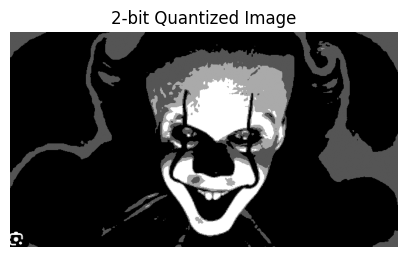

In [32]:
if gray_img_orig is not None:
    quantized_img_2bit = (gray_img_orig // 64) * 64
    print(f"Quantized Image (2-bit) Data Type: {quantized_img_2bit.dtype}")
    print(f"Quantized Image (2-bit) unique levels: {np.unique(quantized_img_2bit).size}")
    plt.figure(figsize=(5, 5))
    plt.imshow(quantized_img_2bit, cmap='gray')
    plt.title('2-bit Quantized Image')
    plt.axis('off')
    plt.show()

#### Task 3: Compare file size before and after quantization.
#### Task 4: Save the quantized image using `cv2.imwrite()`.

In [33]:
if gray_img_orig is not None and quantized_img_4bit is not None:
    # Define output paths
    output_original_grayscale = 'original_grayscale.png'
    output_quantized_4bit = 'quantized_4bit.png'

    # Save images
    cv2.imwrite(output_original_grayscale, gray_img_orig)
    cv2.imwrite(output_quantized_4bit, quantized_img_4bit)

    print(f"Original grayscale image saved to {output_original_grayscale}")
    print(f"4-bit quantized image saved to {output_quantized_4bit}")

    # Get file sizes
    size_original = os.path.getsize(output_original_grayscale)
    size_quantized = os.path.getsize(output_quantized_4bit)

    print(f"File size of original grayscale image: {size_original} bytes")
    print(f"File size of 4-bit quantized image: {size_quantized} bytes")

    if size_original > size_quantized:
        print("File size decreased after quantization.")
    elif size_original < size_quantized:
        print("File size increased after quantization. (This can happen if the original image had very few colors and PNG compression is more efficient for it, or if the quantized image has specific patterns that lead to less efficient compression.)")
    else:
        print("File size remained the same after quantization.")
else:
    print("Images not available for file size comparison and saving.")

Original grayscale image saved to original_grayscale.png
4-bit quantized image saved to quantized_4bit.png
File size of original grayscale image: 77979 bytes
File size of 4-bit quantized image: 27058 bytes
File size decreased after quantization.
